In [6]:
import numpy as np
import matplotlib as mpl
import pandas as pd
from numpy.random import multivariate_normal
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import mixture
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons,make_blobs
from sklearn.metrics import accuracy_score

A couple of helper functions we can use:

In [7]:
def sample_2d_gaussian(meanx,meany,variance_x,variance_y,covariance,numsamps):
    '''
    Generates a random sample of size 'numsamps' from a 2-dimensional Gaussian distribution.
    The Gaussian is defined by the mean vector (meanx,meany) and the covariance matrix
    
    variance_x    covariance
    covariance    variance_y
    
    All parameters can be freely chosen, except covariance, which must satisfy the inequality
    
    covariance <= sqrt(variance_x * variance_y)
    '''
    meanvec = np.array([meanx,meany])
    covarmatrix = np.array([[variance_x,covariance],[covariance,variance_y]])
    return multivariate_normal(meanvec,covarmatrix,numsamps)


def maxpos(A):
    '''
    Takes an n x k array A, and returns 1-dim n array where the i'th
    entry is the index of column in A where the i'th row of A has its
    maximal value (application: turns a probabilitiy distribution over
    k classes for n instances into a single prediction)
    '''
    return np.argmax(A,axis=1)
    

### Part 1: Decision regions for simple 2 dimensional datasets

Loading/generating data: following are two alternative ways (A and B) to get data consisting of the input features stored in 'features', and the class labels, stored in 'labels'.  Only execute one of the data generating cells, before moving on to the following code!

**A**: sampling data from 2-dimensional Gaussian distributions. For reproducibility, one can fix a random seed.

In [8]:
np.random.seed(1)
datasize=250
mixturecoeff=np.array([0.4,0.2,0.4])
componentsizes=(datasize*mixturecoeff).astype(int)

class0samp=sample_2d_gaussian(2,3,0.5,0.5,0.45,componentsizes[0])
class1samp=sample_2d_gaussian(5,3,1.0,0.5,-0.45,componentsizes[1])
class2samp=sample_2d_gaussian(3,2,0.5,0.5,0,componentsizes[2])
  
  
features=np.concatenate((class0samp,class1samp,class2samp),axis=0)
labels=np.concatenate((np.zeros(componentsizes[0]),np.ones(componentsizes[1]),2*np.ones(componentsizes[2])))         

In [9]:
features.shape

(250, 2)

**B**: Loading mi.txt data:

In [10]:
midata = pd.read_csv("./MI-labeled.txt", sep=',')
features = np.array(midata[['X1','X2']])
classlabels=midata['Class']
labels = np.zeros(len(classlabels))
for i in range(len(classlabels)):
    if classlabels[i] == 'I':
        labels[i]=1

Plotting the data with labels indicated by color:

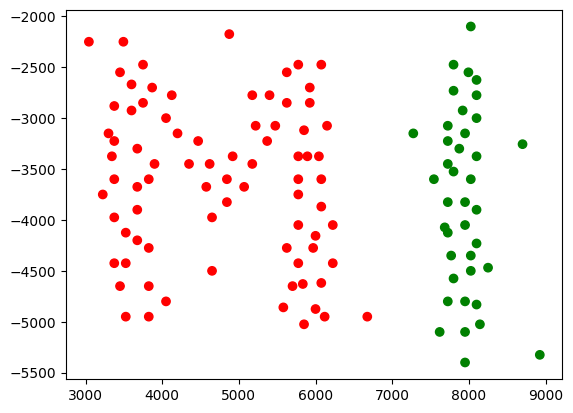

In [11]:
plt.scatter(features[:,0],features[:,1],c=labels, cmap = mpl.colors.ListedColormap(['r', 'b','g']))
plt.show()

Preparing meshgrid for plotting decision regions:

In [12]:
maxvalx = np.max(features[:,0])
maxvaly = np.max(features[:,1])
minvalx = np.min(features[:,0])
minvaly = np.min(features[:,1])
border=2
xinterval = (maxvalx-minvalx)/border
yinterval = (maxvaly-minvaly)/border
xx, yy = np.meshgrid(np.arange(minvalx-xinterval, maxvalx+xinterval, xinterval/100), np.arange(minvaly-yinterval, maxvaly+yinterval, yinterval/100))
      

Learning a classifier -- uncomment to select the classification model to use.

In [13]:
model=LinearDiscriminantAnalysis()
# model = LogisticRegression()
model = SVC(kernel='linear')

model.fit(features,labels)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [14]:
features.shape

(119, 2)

Applying model to the meshgrid. All models return a quantitative "likelihood" for the different classes. For the probabilistic models, these are class label probabilities that are retrieved using the `.predict_proba` method. For the non-probabilistic SVC model, this is the `decision_function` method. In all cases, we classify a datapoint as belonging to the class with the maximal "likelihood" value.

In [15]:
# Z=model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z=model.decision_function(np.c_[xx.ravel(), yy.ravel()])

# meshclasses = maxpos(Z)
##Use the following two lines when Z=model.decision_function() instead of meshclasses = maxpos(Z) 
meshclasses = np.ones(Z.size)
meshclasses[Z<0]=0

meshclasses = meshclasses.reshape(xx.shape)

Plotting datapoints and decision regions

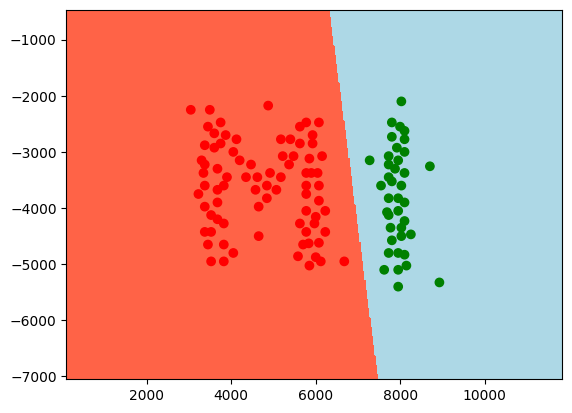

In [16]:
plt.contourf(xx,yy,meshclasses,[-0.1,0.1,1,2],colors=('tomato','lightblue','lightgreen'))
plt.scatter(features[:,0],features[:,1],c=labels, cmap = mpl.colors.ListedColormap(['r', 'b','g']))
#plt.scatter(data[:,0],data[:,1],c=classlabels_numeric, cmap = mpl.colors.ListedColormap(['r', 'b']))
plt.show()

We also calculate the predictions on the (training) datapoints, and check the accuracy:

In [17]:
pred_labels=model.predict(features)
print("Accuracy: {}".format(accuracy_score(labels,pred_labels)))

Accuracy: 1.0


**Exercise 1**: Experiment with the three classifiers Linear Discriminant Analysis, Logistic Regression, and linear support vector machines. Use the MI data, and different mixtures of Gaussians you create by varying the parameters in `sample_2d_gaussian'. 

For the Gaussian mixture data:

Create one or several linearly separable Gaussian mixture datasets (can be with only two components) for which some of the models give a perfect separation of the classes, and others don't (this is related to Exercise 4 in self study 1). 

Create separate test sets using the same parameters for the Gaussian mixture as in the creation of the training set. Can you create a test/train dataset and find classifiers A and B, such that A is better than B on the training data, but B is better than A on the test set? Why is this not such an easy task for the datasets and classifiers we consider her?

For the MI data:

explain the structure of the decision regions you find for the different classifiers.


### Part A: Linearly separable Gaussian Mixtures

In [18]:
# Linearly separable dataset
np.random.seed(42) # Use a fixed seed for repeatabilty

# Two separated Gaussians
class0samp = sample_2d_gaussian(meanx=1,meany=1, variance_x=0.3, variance_y= 0.3, covariance=0, numsamps=100)
class1samp = sample_2d_gaussian(meanx=4,meany=4, variance_x=0.3, variance_y= 0.3, covariance=0, numsamps=100)

features = np.concatenate((class0samp, class1samp), axis=0)
print(features.shape)
labels = np.concatenate((np.zeros(100), np.ones(100)))

(200, 2)


In [19]:
# Overlapping or non linearly separable class
np.random.seed(42) # Use a fixed seed for repeatabilty

# cluster in one center
class0samp = sample_2d_gaussian(meanx=0,meany=0, variance_x=0.5, variance_y=0.5, covariance=0, numsamps=100)

# dispersed/overlapping
class1samp = sample_2d_gaussian(meanx=1,meany=1, variance_x=1.5, variance_y=1.5, covariance=0.8, numsamps=100)

features = np.concatenate((class0samp, class1samp), axis=0)
print(features.shape)
labels = np.concatenate((np.zeros(100), np.ones(100)))

(200, 2)


In [20]:
from sklearn.model_selection import train_test_split

features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.3, random_state=42)

models = {
    'LDA' : LinearDiscriminantAnalysis(),
    'Logistic Regression' : LogisticRegression(),
    'SMV (linear)' : SVC(kernel='linear')
}

for name, model in models.items():
    model.fit(features_train, labels_train)
    train_acc = accuracy_score(labels_train, model.predict(features_train))
    test_acc = accuracy_score(labels_test, model.predict(features_test))
    print(f"{name} - Train {train_acc:.3f}, Test: {test_acc:.3f}")

LDA - Train 0.721, Test: 0.750
Logistic Regression - Train 0.693, Test: 0.767
SMV (linear) - Train 0.714, Test: 0.750


### Part B: MI Data Analysis

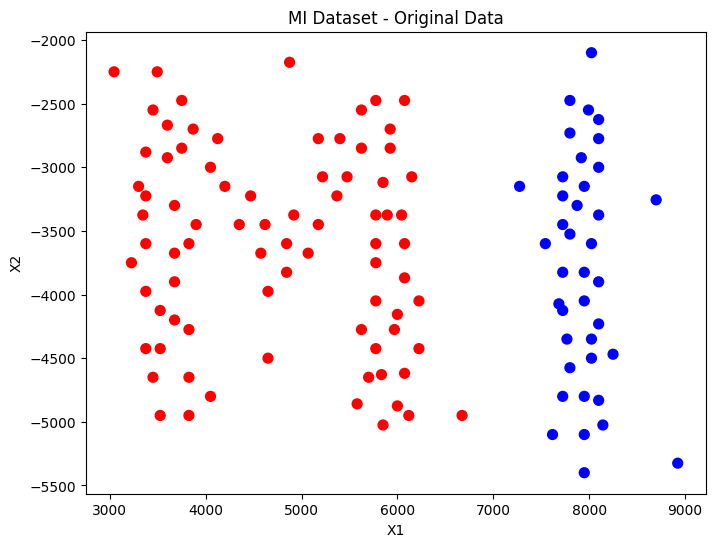

In [21]:
midata = pd.read_csv("./MI-labeled.txt", sep=',')
features = np.array(midata[['X1','X2']])
classlabels = midata['Class']
labels = np.zeros(len(classlabels))
for i in range(len(classlabels)):
    if classlabels[i] == 'I':
        labels[i] = 1

# Plot the raw data
plt.figure(figsize=(8, 6))
plt.scatter(features[:,0], features[:,1], c=labels, cmap=mpl.colors.ListedColormap(['red', 'blue']), s=50)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('MI Dataset - Original Data')
plt.show()

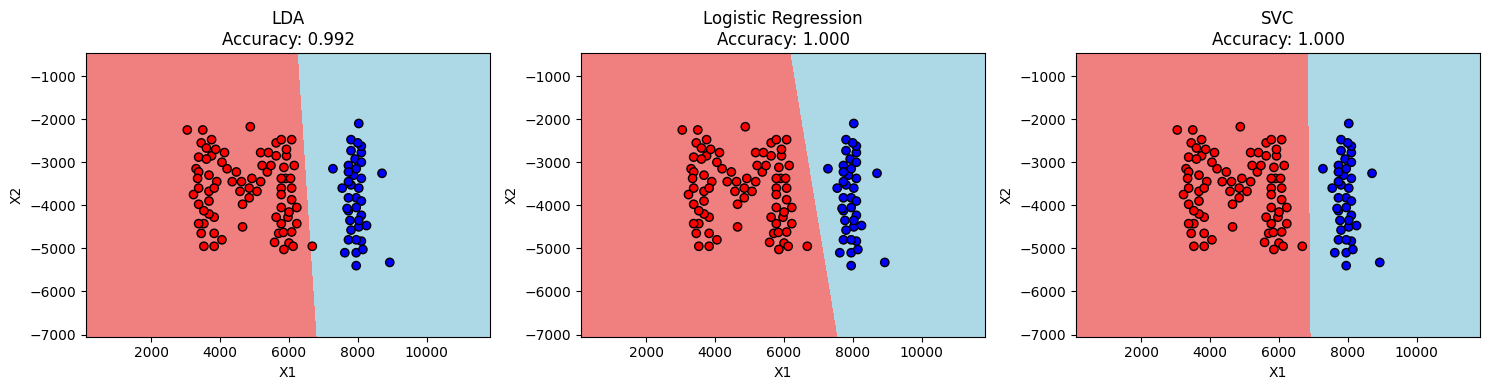

In [22]:
# Create meshgrid (from existing code)
maxvalx = np.max(features[:,0])
maxvaly = np.max(features[:,1])
minvalx = np.min(features[:,0])
minvaly = np.min(features[:,1])
border = 2
xinterval = (maxvalx - minvalx) / border
yinterval = (maxvaly - minvaly) / border
xx, yy = np.meshgrid(
    np.arange(minvalx - xinterval, maxvalx + xinterval, xinterval/100),
    np.arange(minvaly - yinterval, maxvaly + yinterval, yinterval/100)
)

# Train and plot each classifier
classifiers = {
    'LDA': LinearDiscriminantAnalysis(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVC': SVC()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, model) in enumerate(classifiers.items()):
    model.fit(features, labels)
    
    # Get predictions on meshgrid
    if name == "SVC":
        Z=model.decision_function(np.c_[xx.ravel(), yy.ravel()])
        meshclasses = np.ones(Z.size)
        meshclasses[Z<0]=0
        meshclasses = meshclasses.reshape(xx.shape)
    else:
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
        meshclasses = maxpos(Z).reshape(xx.shape)
    
    # Plot decision region
    axes[idx].contourf(xx, yy, meshclasses, [-0.1, 0.5, 1.1], colors=('lightcoral', 'lightblue'))
    axes[idx].scatter(features[:,0], features[:,1], c=labels, cmap=mpl.colors.ListedColormap(['red', 'blue']), edgecolors='black')
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(labels, model.predict(features)):.3f}')
    axes[idx].set_xlabel('X1')
    axes[idx].set_ylabel('X2')

plt.tight_layout()
plt.show()

Boundary Shape
LDA: Straight lines (linear boundaries)
The mean vector for this model pulls the decision boundary more in the direction of the red values creating a small error for one data point.

Logistic Regression: Straight lines (also linear)
SV: Straight lines (linear kernel)

The other two approaches are able to find a linear division that perfectly divides the two clusters of data without any error.


How do the angles/positions of boundaries differ?
Where do they misclassify points?
Which handles edge cases better?
Data Structure Insights

Are the classes well-separated or overlapping?
Is a linear boundary sufficient or would non-linear help?
Which features matter more (X1 or X2)?

### Part 2: the California Housing data

We next investigate some "real" data: the California housing dataset contains attributes characterizing houses in different "blocks" of California, and the median house value in these blocks. The usual machine learning problem for this dataset is the regression problem of predicting the median value. We can turn it into a binary prediction problem whether the median value is above the median (of the median values). 

The `fetch_california_housing` function returns the dataset in the form of a dictionary with attributes DESCR, data, and target.

In [23]:
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing()


# print(california_housing['DESCR'])

For a first illustration, we plot the datapoints by geographic coordinates with color coded median house prices:

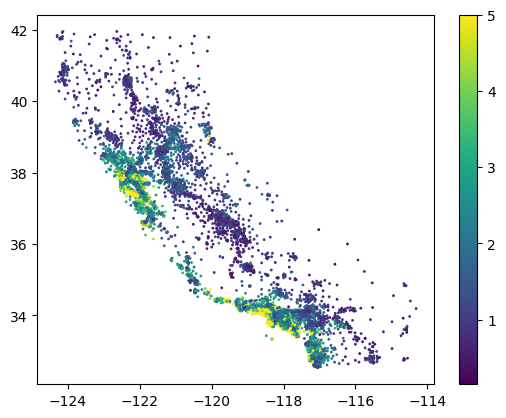

In [24]:
plt.scatter(california_housing['data'][:,7],california_housing['data'][:,6],s=1,c=california_housing['target'])
plt.colorbar()
plt.show()

We generate our binary labels, and create a train/test split:

In [25]:
labels = np.array([1 if y > np.median(california_housing['target']) else 0 for y in california_housing['target']])
features = california_housing['data']
features_train,features_test,labels_train,labels_test = train_test_split(features,labels)

After this discretization the data looks as follows (showing the full data, not train or test splits):

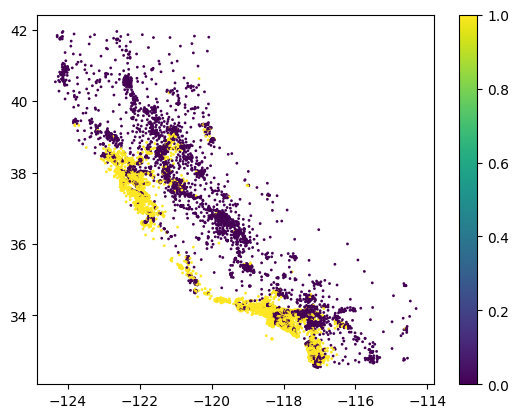

In [26]:
plt.scatter(california_housing['data'][:,7],california_housing['data'][:,6],s=1,c=labels)
plt.colorbar()
plt.show()

One can directly see that the coordinates are already pretty good predictors, though clearly not allowing for linear separbility. We investigate how good a model we get by using all features and different model classes: 

**Exercise 2**: Try the different models on the California housing data. Which one is doing best in terms of test accuracy?

Inspect the following attributes of the learned models:


LDA: `means_` <br>
Logistic regression: `coef_` <br>
SVC: `coef_`<br>

Check the online documentation about the meaning of these attributes. How can the values of these attributes be used for explaining the classification model? Which of the input features are most important for the prediction? 

For this investigation it may be helpful to normalize the data before building the classifiers, using the code in the cell below (why is this useful?).



In [27]:
# Normalizing data
from sklearn.preprocessing import StandardScaler

# Fit scaler only on train data
scaler = StandardScaler()
scaler.fit(features_train)

features_train_norm = scaler.transform(features_train)
features_test_norm = scaler.transform(features_test)

print(f"Mean of normalized training features (should be ~0):\n{features_train_norm.mean(axis=0)}")
print(f"Std of normalized training features (should be ~1):\n{features_train_norm.std(axis=0)}")

Mean of normalized training features (should be ~0):
[-6.61128488e-15  1.73002583e-16  3.01379830e-15 -1.05715528e-15
 -2.81572067e-17  1.40727896e-15  1.18810352e-13 -3.38652964e-13]
Std of normalized training features (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1.]


> [!note] \
> without normalization the SVC-L will train for an indefinite amount of time

In [28]:
# Uncomment one of the following:
classifiers = {
    "LDA": LinearDiscriminantAnalysis(),
    "LG": LogisticRegression(max_iter=1000),
    "SVC-L": SVC(kernel='linear'),
}

results = {}

for name, model in classifiers.items():
    model.fit(features_train_norm,labels_train)
    pred_labels_train=model.predict(features_train_norm)
    pred_labels_test=model.predict(features_test_norm)

    train_acc = accuracy_score(labels_train,pred_labels_train)
    test_acc = accuracy_score(labels_test,pred_labels_test)

    print(f"-----{name}-----")
    print(f"Accuracy train: {train_acc:.4f}")
    print(f"Accuracy test: {test_acc:.4f}")

    results[name] = {
        "model" : model,
        "train_acc" : train_acc,
        "test_acc" : test_acc
    }



-----LDA-----
Accuracy train: 0.8198
Accuracy test: 0.8110
-----LG-----
Accuracy train: 0.8278
Accuracy test: 0.8221
-----SVC-L-----
Accuracy train: 0.8399
Accuracy test: 0.8391


Inspect the following attributes of the learned models:


LDA: `means_` <br>
Logistic regression: `coef_` <br>
SVC: `coef_`<br>



In [29]:
lda_model = results['LDA']['model']

feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

print("LDA Class Means (per feature):")
print("Feature names:", feature_names)
print("Class 0 means:", lda_model.means_[0])
print("Class 1 means:", lda_model.means_[1])
print("\nDifference (Class 1 - Class 0):")
print(lda_model.means_[1] - lda_model.means_[0])

# Interpretation: Large differences = important features
print("\nFeature Importance (by absolute mean difference):")
importance = np.abs(lda_model.means_[1] - lda_model.means_[0])
for fname, imp in zip(feature_names, importance):
    print(f"{fname:15s}: {imp:.4f}")

LDA Class Means (per feature):
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Class 0 means: [-0.52369442 -0.07301883 -0.09853153  0.06129909 -0.00228461  0.02198817
  0.13751113  0.04951218]
Class 1 means: [ 0.51965045  0.07245498  0.09777067 -0.06082574  0.00226697 -0.02181838
 -0.13644927 -0.04912985]

Difference (Class 1 - Class 0):
[ 1.04334488  0.14547381  0.1963022  -0.12212482  0.00455159 -0.04380654
 -0.2739604  -0.09864204]

Feature Importance (by absolute mean difference):
MedInc         : 1.0433
HouseAge       : 0.1455
AveRooms       : 0.1963
AveBedrms      : 0.1221
Population     : 0.0046
AveOccup       : 0.0438
Latitude       : 0.2740
Longitude      : 0.0986


In [30]:
lr_model = results['LG']['model']

feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

print("Logistic Regression Coefficients:")
coef = lr_model.coef_[0]

for fname, coeff in zip(feature_names, coef):
    print(f"{fname:15s}: {coeff:10.6f}")

print("\nFeature Importance (by absolute coefficient value):")
importance = np.abs(coef)
sorted_idx = np.argsort(importance)[::-1]

for idx in sorted_idx:
    print(f"{feature_names[idx]:15s}: {importance[idx]:.6f}")

Logistic Regression Coefficients:
MedInc         :   2.576095
HouseAge       :   0.271227
AveRooms       :  -0.830266
AveBedrms      :   0.953048
Population     :   0.067691
AveOccup       :  -2.225922
Latitude       :  -3.674964
Longitude      :  -3.488985

Feature Importance (by absolute coefficient value):
Latitude       : 3.674964
Longitude      : 3.488985
MedInc         : 2.576095
AveOccup       : 2.225922
AveBedrms      : 0.953048
AveRooms       : 0.830266
HouseAge       : 0.271227
Population     : 0.067691


In [31]:
svm_model = results['SVC-L']['model']

feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

print("SVM Linear Kernel Coefficients:")
coef = svm_model.coef_[0]

for fname, coeff in zip(feature_names, coef):
    print(f"{fname:15s}: {coeff:10.6f}")

print("\nFeature Importance (by absolute coefficient value):")
importance = np.abs(coef)
sorted_idx = np.argsort(importance)[::-1]

for idx in sorted_idx:
    print(f"{feature_names[idx]:15s}: {importance[idx]:.6f}")

SVM Linear Kernel Coefficients:
MedInc         :   1.865224
HouseAge       :   0.223168
AveRooms       :  -0.612544
AveBedrms      :   0.707543
Population     :   0.073912
AveOccup       :  -4.876594
Latitude       :  -2.808083
Longitude      :  -2.622080

Feature Importance (by absolute coefficient value):
AveOccup       : 4.876594
Latitude       : 2.808083
Longitude      : 2.622080
MedInc         : 1.865224
AveBedrms      : 0.707543
AveRooms       : 0.612544
HouseAge       : 0.223168
Population     : 0.073912


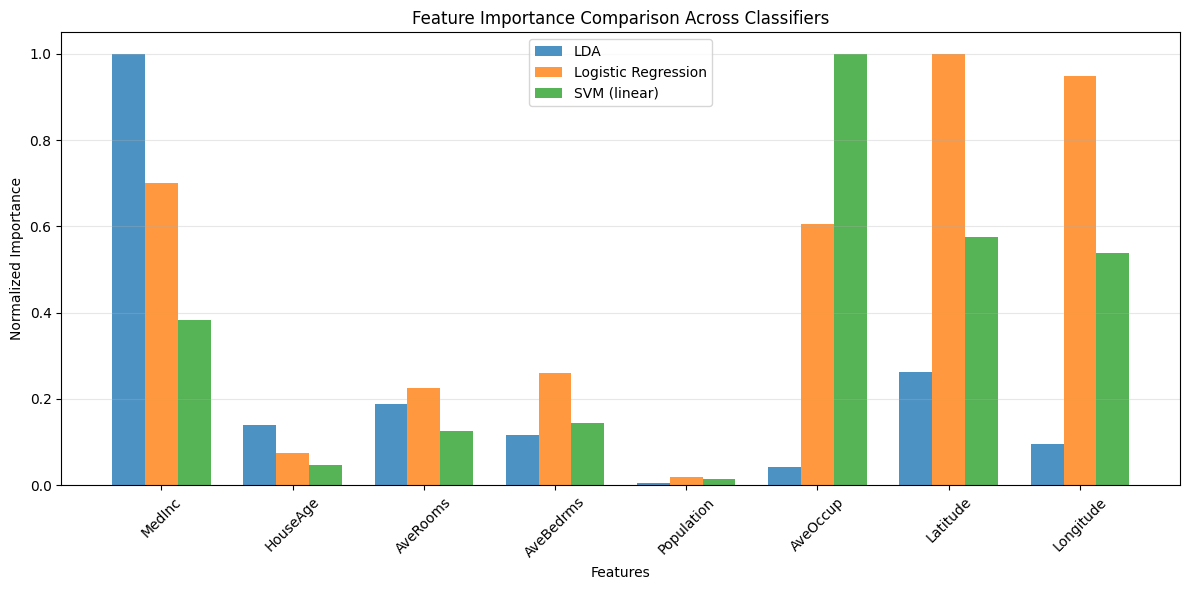

In [32]:
import matplotlib.pyplot as plt

feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

# Collect importances
lda_importance = np.abs(results['LDA']['model'].means_[1] - results['LDA']['model'].means_[0])
lr_importance = np.abs(results['LG']['model'].coef_[0])
svm_importance = np.abs(results['SVC-L']['model'].coef_[0])

# Normalize for comparison
lda_importance = lda_importance / lda_importance.max()
lr_importance = lr_importance / lr_importance.max()
svm_importance = svm_importance / svm_importance.max()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(feature_names))
width = 0.25

ax.bar(x - width, lda_importance, width, label='LDA', alpha=0.8)
ax.bar(x, lr_importance, width, label='Logistic Regression', alpha=0.8)
ax.bar(x + width, svm_importance, width, label='SVM (linear)', alpha=0.8)

ax.set_xlabel('Features')
ax.set_ylabel('Normalized Importance')
ax.set_title('Feature Importance Comparison Across Classifiers')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Analysis Summary

**1. Which model performs best on test accuracy?**
```
-----LDA-----
Accuracy train: 0.8198
Accuracy test: 0.8110
-----LG-----
Accuracy train: 0.8278
Accuracy test: 0.8221
-----SVC-L-----
Accuracy train: 0.8399
Accuracy test: 0.8391
```

On test accuracy the best perfromance is achieved by SVC with a linear kernel

**2. Why is normalization important for this analysis?**
- Without normalization, features with larger scales (like MedInc in thousands) would dominate
- Normalized features have zero mean and unit variance, so coefficients are directly comparable
- Raw coefficients would be misleading because they're on different scales

**3. Which features are most important for predicting house prices?**
The different models do not agree on the most important features. The following is a top 3 per model.

For LDA:
1. MedInc
2. Latitude
3. AveRooms

For LR:
1. Latitude
2. Longitude
3. MedInc

for SVM:
1. AverageOccupancy
2. Latitude
3. Longitude

**4. Interpretation of model predictions:**
- **LDA**: Large mean differences in income and latitude drive the classification
- **Logistic Regression**: The model heavily weights income and latitude and longitude.
    a large positive coefficient increases probability of class 1 and viceversa.
    ```
    Logistic Regression Coefficients:
    MedInc         :   2.576095
    HouseAge       :   0.271227
    AveRooms       :  -0.830266
    AveBedrms      :   0.953048
    Population     :   0.067691
    AveOccup       :  -2.225922
    Latitude       :  -3.674964
    Longitude      :  -3.488985
    ```

- **SVM**: Similar to logistic regression, emphasizes geographic features (Latitude/Longitude) and occupancy

**5. Why might the models agree or disagree on feature importance?**
Model Differences:

- LDA assumes: Classes come from Gaussian distributions with shared variance structure
    
    > LDA thinks: "Where are class 0 points centered vs. class 1 points centered?"

    * It looks at differences in class means
    * It assumes the data has a specific probabilistic structure

    * Calculates the mean (average location) of each class
        * It looks at the difference between these means
        * Features with large mean differences are important

    The model assumption gives more importance to income because the difference in for that feature is higher while the latitude might not vary that much.

- Logistic Regression assumes: A linear decision boundary separates classes

    > LR thinks: "What coefficients best predict class 1 probability?"

    * It learns coefficients to maximize likelihood
    * It's more flexible about data distribution


    * LR learns weights (coefficients) for each feature
    * It optimizes to maximize the probability of correct predictions
    * Features that change the prediction most get larger coefficients(in this case the geographic position)

    LR cares more about boundaries between classes in this case latitude and longitude rappresent a strong geographic pattern costal is way more expensive than central valley

- SVM assumes: Find the boundary that maximizes margin between classes

    > SVM thinks: "Which decision boundary keeps the classes most separated from it?"

    * It uses the support vectors (closest points)
    * Different optimization objective than LR

    * SVM cares about the **closest points** to the decision boundary (support vectors)
    * It wants to maximize the distance from the boundary to the nearest points
    * Features that help push classes apart matter most

    SVM might care more about spatial separation (which features define the boundary position). This is similar to LR: both care about the decision boundary itself.



# TLDR
The three models disagree because they **optimize for different objectives**:

#### LDA: Mean-based approach
- LDA assumes classes come from Gaussian distributions
- It identifies important features by looking at **differences in class means**
- Result: MedInc
- This explains why LDA emphasizes income highly

#### Logistic Regression & SVM: Boundary-based approach
- LR learns coefficients to maximize likelihood of correct predictions
- SVM maximizes the margin between classes
- Both care about **which features define the decision boundary**
- Result: Geographic position
- This explains why LR/SVM emphasize [Latitude/Longitude] more

#### Why this matters for California housing:
- Geographic location (Latitude/Longitude) might be the strongest *predictor* of the decision boundary
- Income might differ more in absolute mean value but might be distributed across the decision boundary

